#  Customer Segmentation using RFM Analysis, K-Means Clustering, SQL, and Streamlit
`Identify customer groups based on purchasing behavior so businesses can make targeted marketing decisions.`

This project segments customers to help businesses improve:

- retention
- loyalty
- reactivation
- marketing ROI

# Imports

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns

# Load and Understand Data

In [2]:
df1=pd.read_excel('online_retail_II.xlsx',sheet_name="Year 2009-2010")
df2=pd.read_excel('online_retail_II.xlsx',sheet_name='Year 2010-2011')

In [3]:
df=pd.concat([df1,df2],ignore_index=True)

In [4]:
# first 10 rows 
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [5]:
# last 10 rows 
df.tail(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1067361,581587,22730,ALARM CLOCK BAKELIKE IVORY,4,2011-12-09 12:50:00,3.75,12680.0,France
1067362,581587,22367,CHILDRENS APRON SPACEBOY DESIGN,8,2011-12-09 12:50:00,1.95,12680.0,France
1067363,581587,22629,SPACEBOY LUNCH BOX,12,2011-12-09 12:50:00,1.95,12680.0,France
1067364,581587,23256,CHILDRENS CUTLERY SPACEBOY,4,2011-12-09 12:50:00,4.15,12680.0,France
1067365,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France
1067370,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680.0,France


In [6]:
# columns present 
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='str')

In [7]:
# shape of the data 
df.shape

(1067371, 8)

In [8]:
# info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 78.8+ MB


In [9]:
# check for nulls 
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [10]:
# check for duplicates 
df.duplicated().sum()

34335

In [11]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,1.067371e+06,1067371,1.067371e+06,824364.000000
mean,9.938898e+00,2011-01-02 21:13:55.394029,4.649388e+00,15324.638504
min,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000
25%,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000
50%,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000
75%,1.000000e+01,2011-07-22 10:23:00,4.150000e+00,16797.000000
max,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000
std,1.727058e+02,NaN,1.235531e+02,1697.464450


# Data Cleaning

In [12]:
df=df.drop_duplicates()

In [13]:
# we are droping the rows where customer id is null as it has to be unique and imputing can create fake data 
df=df.dropna(subset='Customer ID')

In [14]:
df.shape

(797885, 8)

In [15]:
df['Invoice'].value_counts()

Invoice
576339     542
579196     533
580727     529
578270     442
573576     435
          ... 
581487       1
581491       1
C581499      1
581566       1
C581568      1
Name: count, Length: 44876, dtype: int64

In [16]:
# in describe we can notice there is negative value for quantity and price which is suspicious
df[df["Invoice"].astype(str).str.startswith("C")]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
...,...,...,...,...,...,...,...,...
1065910,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
1067002,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
1067176,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
1067177,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


In [17]:
df[df['Invoice'].astype(str).str.startswith('C')].shape

(18390, 8)

In [18]:
# removing the negative quantity 
df=df[~df['Invoice'].astype(str).str.startswith('C')]

In [19]:
# Negative quantities - if we keep monetary becomes wrong
(df["Quantity"] < 0).sum()

0

In [20]:
# Zero or negative prices - meaning gifts
df[df["Price"] <= 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
4674,489825,22076,6 RIBBONS EMPIRE,12,2009-12-02 13:34:00,0.0,16126.0,United Kingdom
6781,489998,48185,DOOR MAT FAIRY CAKE,2,2009-12-03 11:19:00,0.0,15658.0,United Kingdom
16107,490727,M,Manual,1,2009-12-07 16:38:00,0.0,17231.0,United Kingdom
18738,490961,22065,CHRISTMAS PUDDING TRINKET POT,1,2009-12-08 15:25:00,0.0,14108.0,United Kingdom
18739,490961,22142,CHRISTMAS CRAFT WHITE FAIRY,12,2009-12-08 15:25:00,0.0,14108.0,United Kingdom
...,...,...,...,...,...,...,...,...
1004540,577129,22464,HANGING METAL HEART LANTERN,4,2011-11-17 19:52:00,0.0,15602.0,United Kingdom
1005014,577168,M,Manual,1,2011-11-18 10:42:00,0.0,12603.0,Germany
1006110,577314,23407,SET OF 2 TRAYS HOME SWEET HOME,2,2011-11-18 13:23:00,0.0,12444.0,Norway
1011446,577696,M,Manual,1,2011-11-21 11:57:00,0.0,16406.0,United Kingdom


In [21]:
df[df["Price"] <= 0].shape

(70, 8)

In [22]:
# removed the 0 price - because they are not generating reveune and monetary is one of the core feature
df=df[df['Price']>0]

In [23]:
# convert customer id to int 
df['Customer ID']=df['Customer ID'].astype(int)

In [24]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,779425.000000,779425,779425.000000,779425.000000
mean,13.489370,2011-01-03 01:44:42.593476,3.218488,15320.360461
min,1.000000,2009-12-01 07:45:00,0.001000,12346.000000
25%,2.000000,2010-07-02 14:39:00,1.250000,13971.000000
50%,6.000000,2010-12-02 14:09:00,1.950000,15247.000000
75%,12.000000,2011-08-01 13:44:00,3.750000,16794.000000
max,80995.000000,2011-12-09 12:50:00,10953.500000,18287.000000
std,145.855814,NaN,29.676140,1695.692775


# EDA ( Exploratory Data Analysis )

In [25]:
df['Total Price']=df['Quantity']*df['Price']

In [26]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Total Price
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


In [27]:
# to get to know the min , max and avg. total price
df['Total Price'].describe()

count    779425.000000
mean         22.291823
std         227.427075
min           0.001000
25%           4.950000
50%          12.480000
75%          19.800000
max      168469.600000
Name: Total Price, dtype: float64

In [28]:
# total unique customer 
df['Customer ID'].nunique()

5878

In [29]:
# order per customer 
customer_orders = df.groupby('Customer ID')['Invoice'].nunique()
customer_orders.describe()

count    5878.000000
mean        6.289384
std        13.009406
min         1.000000
25%         1.000000
50%         3.000000
75%         7.000000
max       398.000000
Name: Invoice, dtype: float64

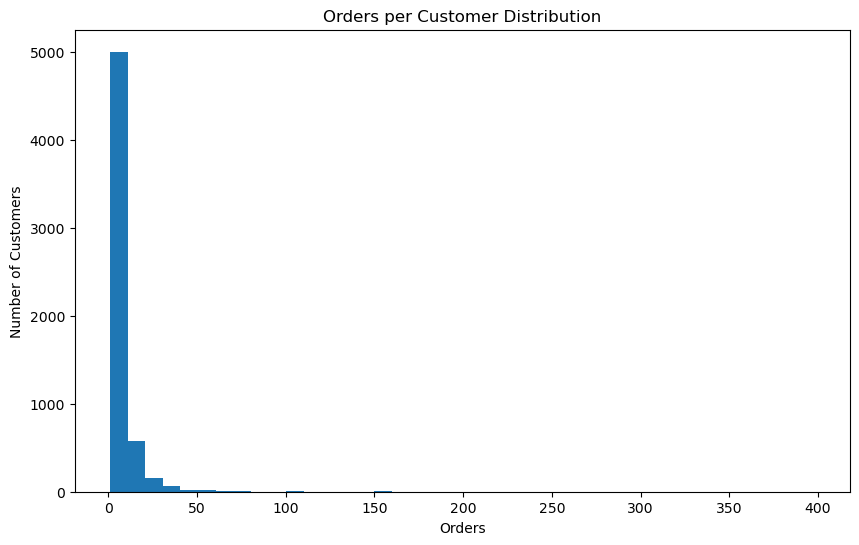

In [30]:
# order histogram 
plt.figure(figsize=(10,6))
plt.hist(customer_orders, bins=40)

plt.title("Orders per Customer Distribution")
plt.xlabel("Orders")
plt.ylabel("Number of Customers")
plt.show()

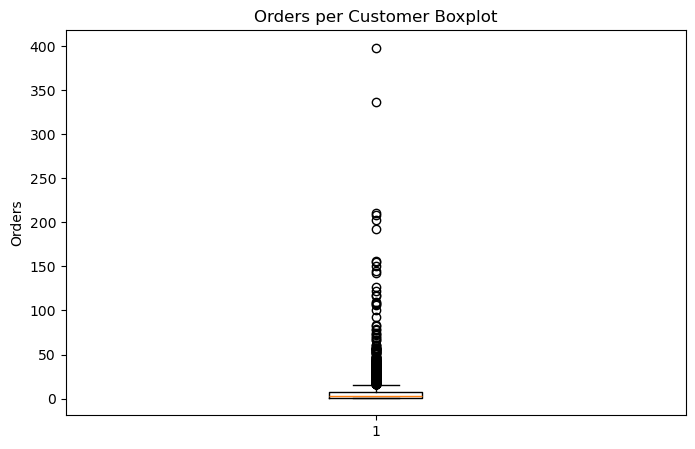

In [31]:
# orders boxplot
plt.figure(figsize=(8,5))
plt.boxplot(customer_orders)

plt.title("Orders per Customer Boxplot")
plt.ylabel("Orders")
plt.show()

In [32]:
# Spending per customer 
customer_spent=df.groupby('Customer ID')['Total Price'].sum()
customer_spent

Customer ID
12346    77556.46
12347     4921.53
12348     2019.40
12349     4428.69
12350      334.40
           ...   
18283     2664.90
18284      461.68
18285      427.00
18286     1296.43
18287     4182.99
Name: Total Price, Length: 5878, dtype: float64

In [33]:
# Spending per customer  - describe
df.groupby('Customer ID')['Total Price'].sum().describe()

count      5878.000000
mean       2955.904095
std       14440.852688
min           2.950000
25%         342.280000
50%         867.740000
75%        2248.305000
max      580987.040000
Name: Total Price, dtype: float64

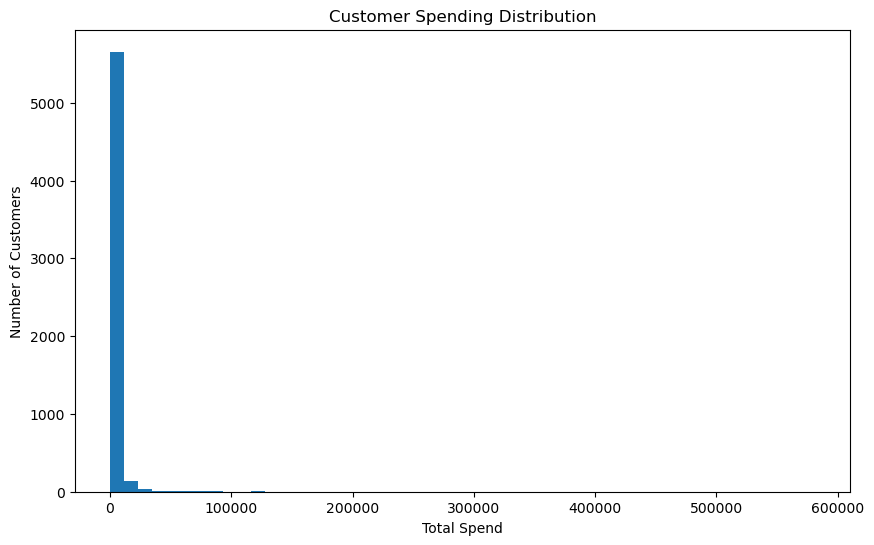

In [34]:
# spending histogram 
plt.figure(figsize=(10,6))
plt.hist(customer_spent, bins=50)

plt.title("Customer Spending Distribution")
plt.xlabel("Total Spend")
plt.ylabel("Number of Customers")
plt.show()

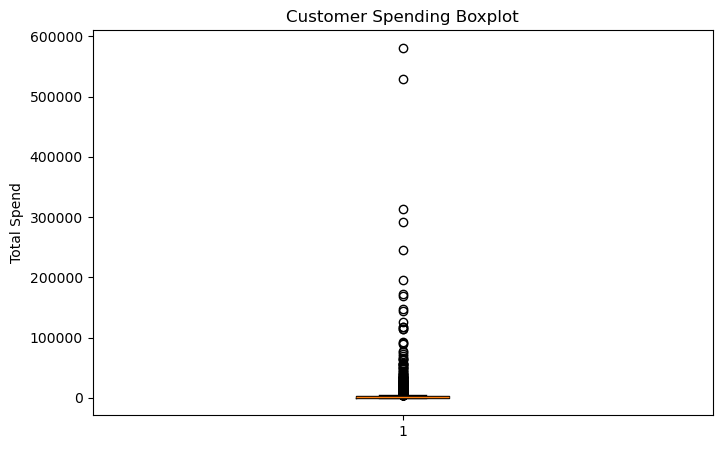

In [35]:
# boxplot 
plt.figure(figsize=(8,5))
plt.boxplot(customer_spent)

plt.title("Customer Spending Boxplot")
plt.ylabel("Total Spend")
plt.show()

In [36]:
# quantity bought per customer 
df.groupby('Customer ID')['Quantity'].sum()

Customer ID
12346    74285
12347     2967
12348     2714
12349     1624
12350      197
         ...  
18283     1679
18284      494
18285      145
18286      608
18287     3013
Name: Quantity, Length: 5878, dtype: int64

In [37]:
# quantity bought per customer  - describe
df.groupby('Customer ID')['Quantity'].sum().describe()

count      5878.000000
mean       1788.695475
std        8876.297196
min           1.000000
25%         187.000000
50%         480.000000
75%        1350.000000
max      367193.000000
Name: Quantity, dtype: float64

In [38]:
# country wise sales 
df.groupby('Country')['Total Price'].sum().sort_values(ascending=False)

Country
United Kingdom          1.438923e+07
EIRE                    6.165705e+05
Netherlands             5.540381e+05
Germany                 4.250197e+05
France                  3.487690e+05
Australia               1.692835e+05
Spain                   1.083325e+05
Switzerland             1.000619e+05
Sweden                  9.151582e+04
Denmark                 6.858069e+04
Belgium                 6.538782e+04
Norway                  5.632250e+04
Portugal                5.555478e+04
Channel Islands         4.462333e+04
Japan                   4.302391e+04
Italy                   3.210817e+04
Finland                 2.992554e+04
Singapore               2.531706e+04
Cyprus                  2.484995e+04
Austria                 2.361301e+04
Greece                  1.909619e+04
Poland                  1.065429e+04
Israel                  1.041524e+04
United Arab Emirates    9.202690e+03
Unspecified             8.607350e+03
USA                     8.366860e+03
Malta                   8.0990

In [39]:
# top 10 country wise sales 
country_sales=df.groupby('Country')['Total Price'].sum().sort_values(ascending=False).head(10)

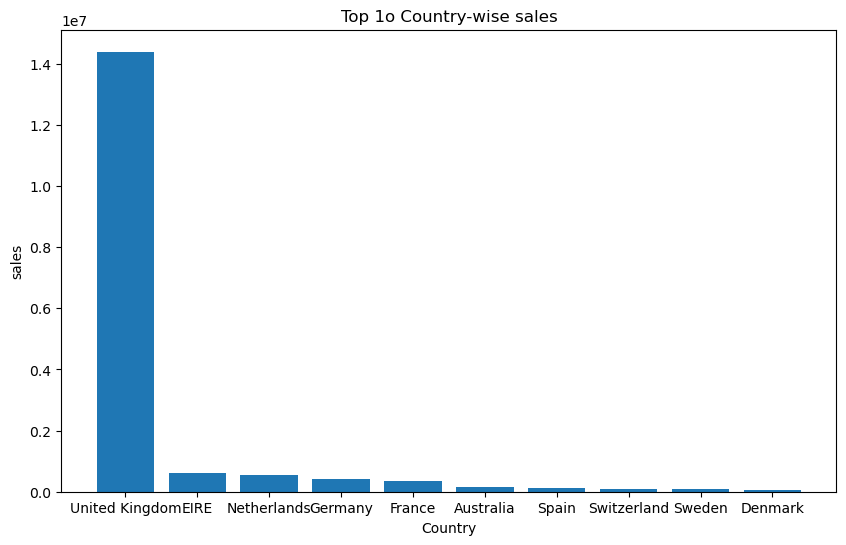

In [40]:
plt.figure(figsize=(10,6))
plt.bar(country_sales.index,country_sales.values)
plt.title("Top 1o Country-wise sales")
plt.xlabel('Country')
plt.ylabel('sales')
plt.show()

# Insights :


In [41]:
# country wise customers
df.groupby("Country")["Customer ID"].nunique()

Country
Australia                 15
Austria                   13
Bahrain                    2
Belgium                   29
Brazil                     2
Canada                     5
Channel Islands           13
Cyprus                    11
Czech Republic             1
Denmark                   12
EIRE                       5
European Community         1
Finland                   14
France                    95
Germany                  107
Greece                     5
Iceland                    1
Israel                     4
Italy                     17
Japan                     10
Korea                      2
Lebanon                    1
Lithuania                  1
Malta                      2
Netherlands               22
Nigeria                    1
Norway                    13
Poland                     6
Portugal                  24
RSA                        2
Saudi Arabia               1
Singapore                  1
Spain                     41
Sweden                    19
Switze

In [42]:
#  top 10 country wise customers
country_wise_customer=df.groupby("Country")["Customer ID"].nunique().sort_values(ascending=False).head(10)

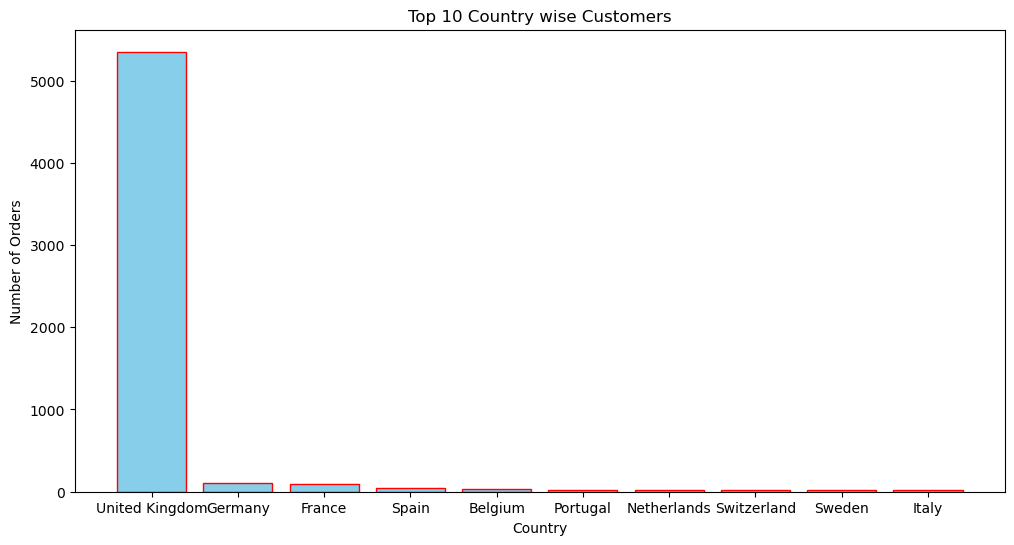

In [43]:
plt.figure(figsize=(12,6))
plt.bar(country_wise_customer.index,country_wise_customer.values,color='skyblue',edgecolor='red')
plt.title("Top 10 Country wise Customers")
plt.xlabel("Country")
plt.ylabel("Number of Orders")
plt.show()

In [44]:
# orders by country 
df.groupby("Country")["Invoice"].nunique()

Country
Australia                  95
Austria                    45
Bahrain                     4
Belgium                   149
Brazil                      2
Canada                      8
Channel Islands            55
Cyprus                     37
Czech Republic              2
Denmark                    43
EIRE                      567
European Community          4
Finland                    57
France                    614
Germany                   789
Greece                     18
Iceland                     8
Israel                      7
Italy                      65
Japan                      33
Korea                       2
Lebanon                     1
Lithuania                   6
Malta                       9
Netherlands               228
Nigeria                     2
Norway                     45
Poland                     28
Portugal                   93
RSA                         2
Saudi Arabia                1
Singapore                  11
Spain                     154
Sw

In [45]:
# top 10 
country_orders =df.groupby("Country")["Invoice"].nunique().sort_values(ascending=False).head(10)

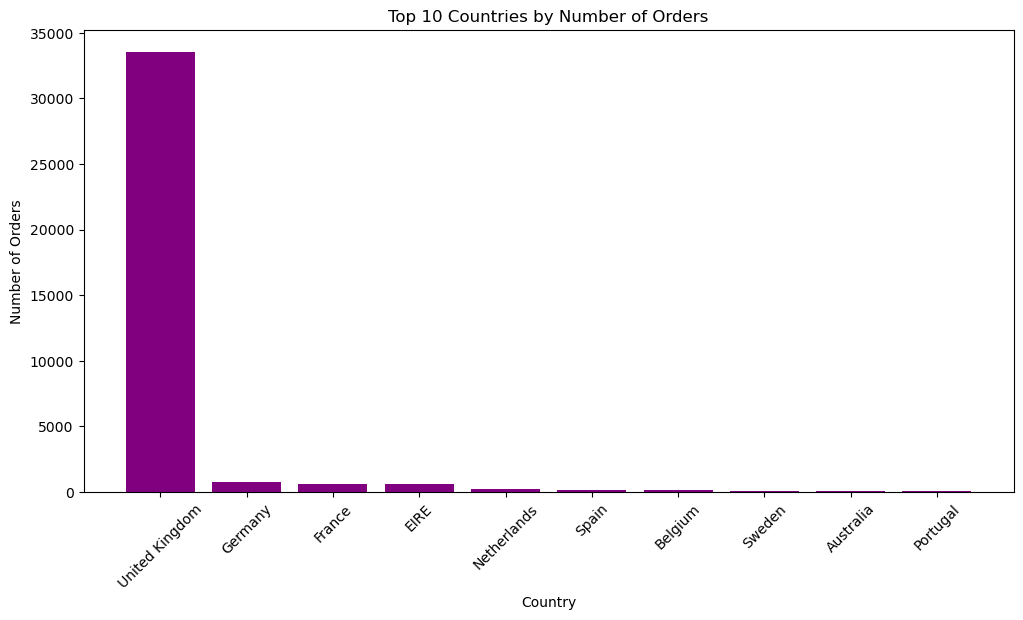

In [46]:
plt.figure(figsize=(12,6))
plt.bar(country_orders.index, country_orders.values,color='purple')

plt.title("Top 10 Countries by Number of Orders")
plt.xlabel("Country")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)
plt.show()

In [47]:
# per month sales 
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")

monthly_sales = df.groupby("YearMonth")["Total Price"].sum()

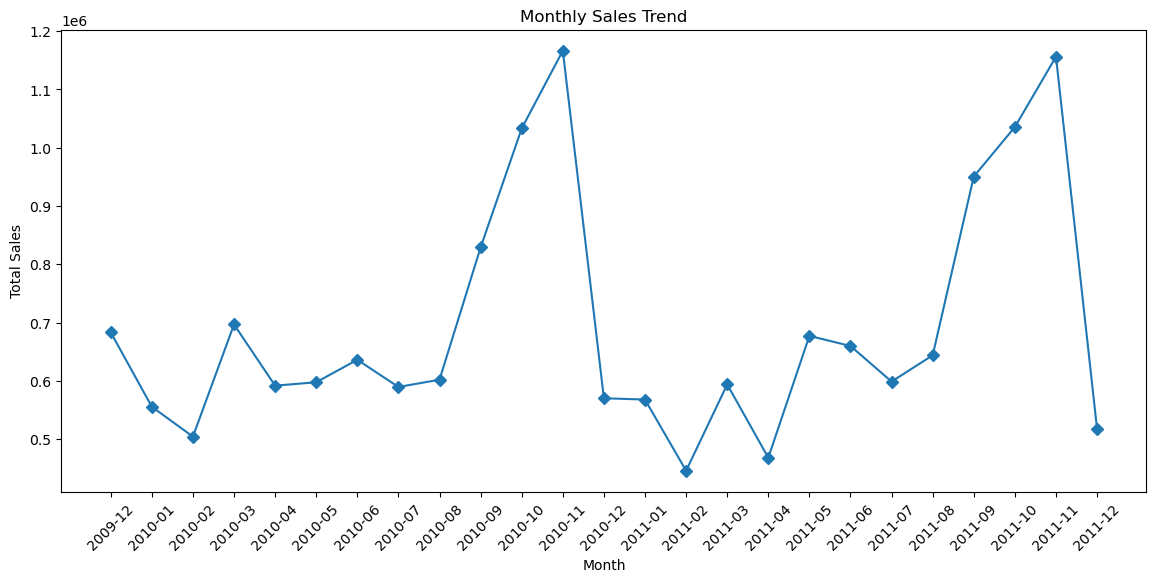

In [48]:
# line chart
plt.figure(figsize=(14,6))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values,marker='D')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.show()

In [49]:
# order over time - shows customer activity 
monthly_orders = df.groupby("YearMonth")["Invoice"].nunique()

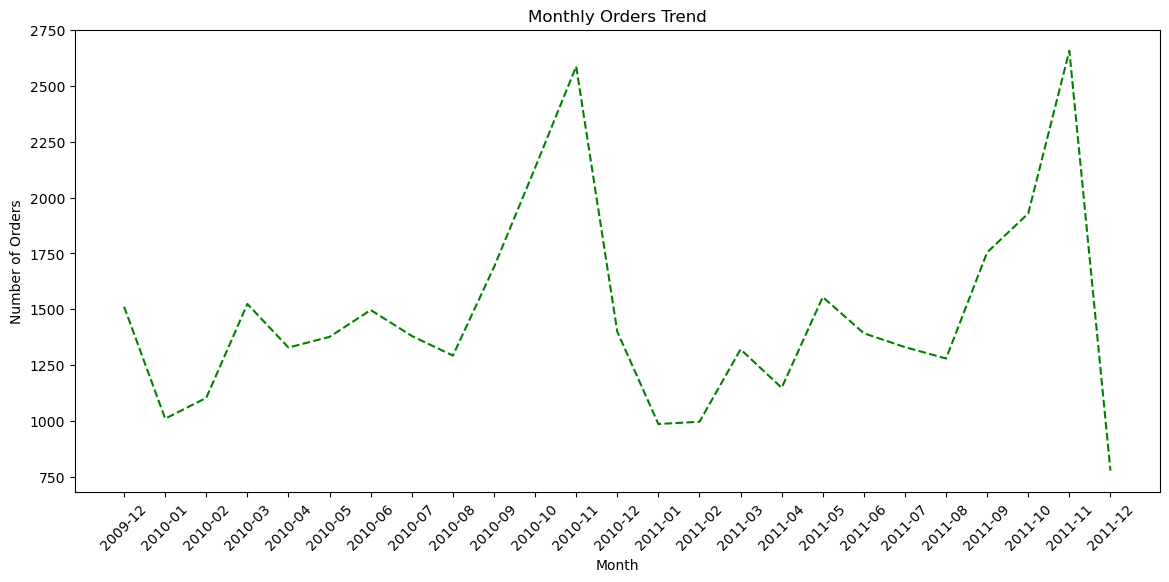

In [50]:
plt.figure(figsize=(14,6))
plt.plot(monthly_orders.index.astype(str), monthly_orders.values,color='green',linestyle='--')

plt.title("Monthly Orders Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)
plt.show()

# RFM Features

In [51]:
# latest transaction date 
latest_date=max(df['InvoiceDate'])
print(latest_date)

refernce_date=latest_date+pd.Timedelta(days=1)
print(refernce_date)


2011-12-09 12:50:00
2011-12-10 12:50:00


In [52]:
# rfm table 
rfm = df.groupby("Customer ID").agg({
    "InvoiceDate": "max",      # latest purchase date
    "Invoice": "nunique",      # number of unique orders
    "Total Price": "sum"       # total money spent
})

In [53]:
rfm['recency']= (refernce_date - rfm["InvoiceDate"]).dt.days

In [54]:
rfm.rename(columns={
    'Invoice':'frequency',
    'Total Price':'monetary'
},inplace=True)

In [55]:
rfm = rfm[['recency','frequency','monetary']]


In [56]:
rfm.head()

,recency,frequency,monetary
Customer ID,,,
12346,326,12,77556.46
12347,2,8,4921.53
12348,75,5,2019.40
12349,19,4,4428.69
12350,310,1,334.40


In [57]:
rfm.tail()

,recency,frequency,monetary
Customer ID,,,
18283,4,22,2664.90
18284,432,1,461.68
18285,661,1,427.00
18286,477,2,1296.43
18287,43,7,4182.99


# Outlier Detection

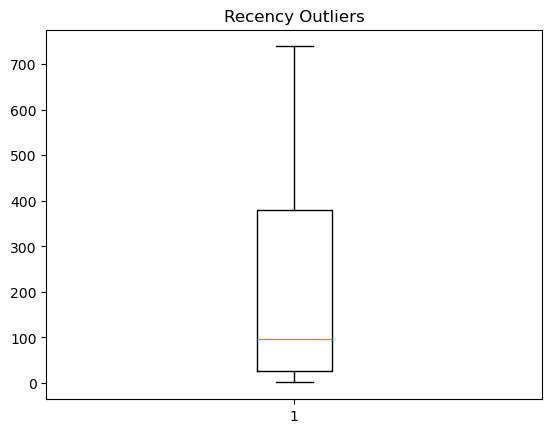

In [58]:
plt.boxplot(rfm['recency'])
plt.title("Recency Outliers")
plt.show()

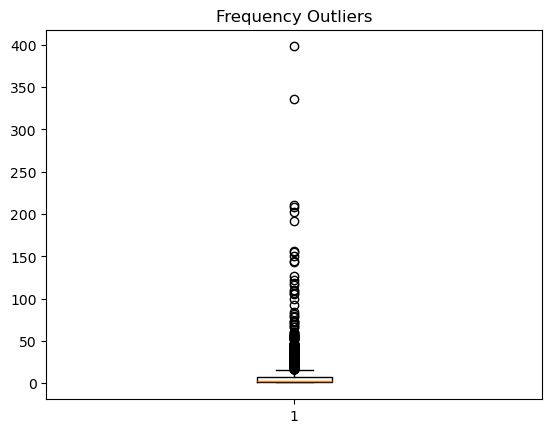

In [59]:
plt.boxplot(rfm['frequency'])
plt.title("Frequency Outliers")
plt.show()

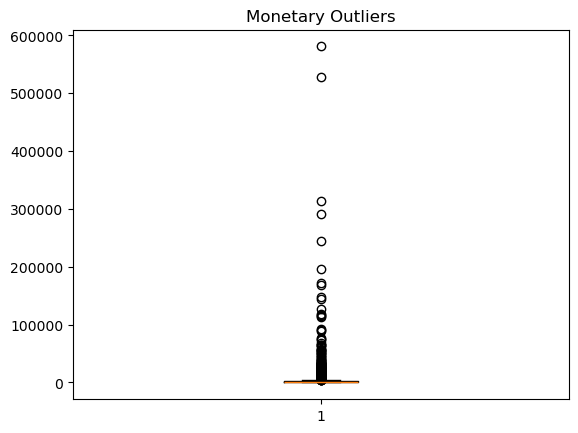

In [60]:
# monentary
plt.boxplot(rfm['monetary'])
plt.title("Monetary Outliers")
plt.show()

In [61]:
# outlier capping 
def cap_outliers(column):
    
    q1 = column.quantile(0.25)
    q3 = column.quantile(0.75)

    iqr = q3 - q1

    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    column = column.clip(lower_limit, upper_limit)

    return column

In [62]:
# apply 
rfm['recency'] = cap_outliers(rfm['recency'])
rfm['frequency'] = cap_outliers(rfm['frequency'])
rfm['monetary'] = cap_outliers(rfm['monetary'])

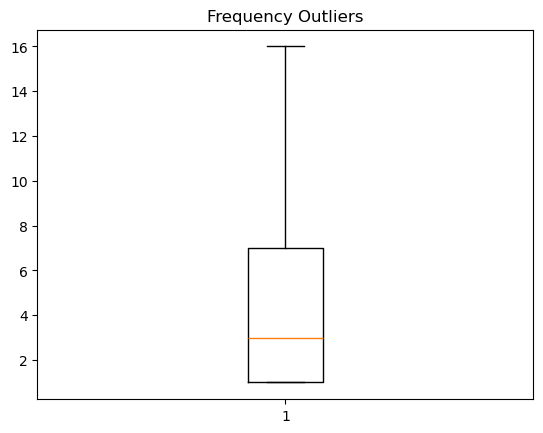

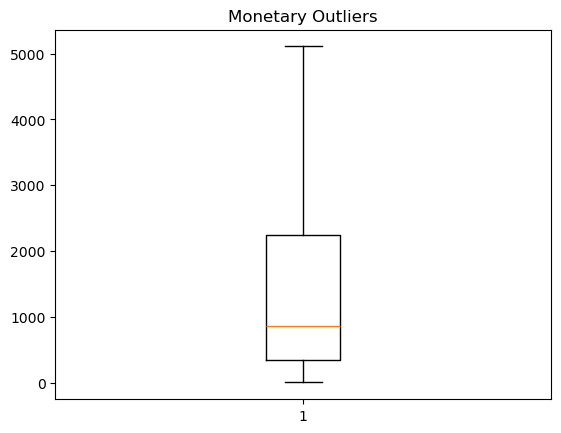

In [63]:
plt.boxplot(rfm['frequency'])
plt.title("Frequency Outliers")
plt.show()

# monentary
plt.boxplot(rfm['monetary'])
plt.title("Monetary Outliers")
plt.show()

# Log transformation

In [64]:
rfm['recency'] = np.log1p(rfm['recency'])
rfm['frequency'] = np.log1p(rfm['frequency'])
rfm['monetary'] = np.log1p(rfm['monetary'])

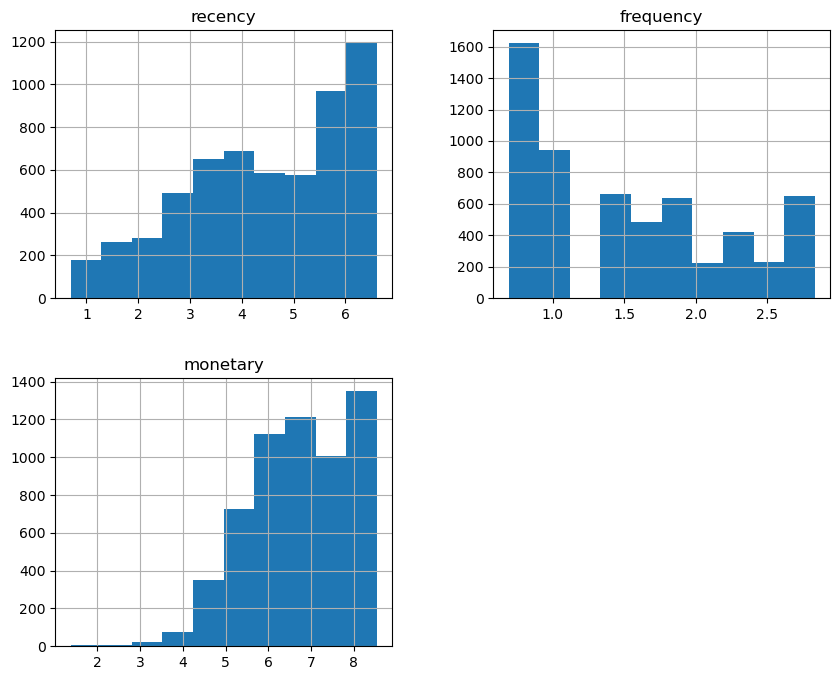

In [65]:
# check distribution 
rfm.hist(figsize=(10,8))
plt.show()

# Standard Scaling

In [66]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

In [67]:
# convert back to dataframe 
rfm_scaled = pd.DataFrame(rfm_scaled,columns=rfm.columns,index=rfm.index)

In [68]:
rfm_scaled.head()

,recency,frequency,monetary
Customer ID,,,
12346,0.856701,1.485452,1.469639
12347,-2.151979,0.968362,1.439451
12348,-0.079138,0.398202,0.713925
12349,-0.935308,0.141823,1.353505
12350,0.824527,-1.146654,-0.749082


# Find Optimal K

In [69]:
from sklearn.cluster import KMeans

inertia = []

for i in range(2,11):
    model = KMeans(n_clusters=i,random_state=42)
    model.fit(rfm_scaled)
    inertia.append(model.inertia_)

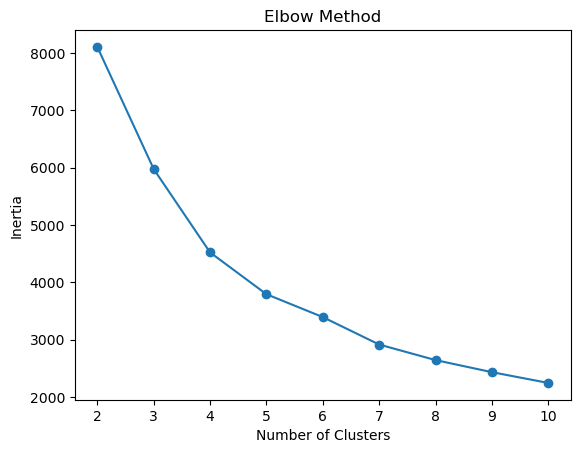

In [70]:
plt.plot(range(2,11),inertia,marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [71]:
from sklearn.metrics import silhouette_score

for i in range(2,11):
    model = KMeans(n_clusters=i,random_state=42)
    cluster_labels = model.fit_predict(rfm_scaled)

    score = silhouette_score(rfm_scaled,cluster_labels)

    print("Clusters:",i,"Score:",score)

Clusters: 2 Score: 0.44768193161680575
Clusters: 3 Score: 0.3543507674196307
Clusters: 4 Score: 0.3844241106905447
Clusters: 5 Score: 0.3399324109914565
Clusters: 6 Score: 0.29636063427171705
Clusters: 7 Score: 0.31057550255512634
Clusters: 8 Score: 0.3099105986303534
Clusters: 9 Score: 0.2948542564202148
Clusters: 10 Score: 0.29946351638402924


# KMeans Clustering

In [72]:
kmeans = KMeans(n_clusters=4,random_state=42)

rfm['cluster'] = kmeans.fit_predict(rfm_scaled)

In [73]:
rfm.head()

,recency,frequency,monetary,cluster
Customer ID,,,,
12346,5.789960,2.564949,8.538630,0
12347,1.098612,2.197225,8.501578,1
12348,4.330733,1.791759,7.611051,0
12349,2.995732,1.609438,8.396085,1
12350,5.739793,0.693147,5.815324,3


# Cluster Evaluation

In [74]:
cluster_summary = rfm.groupby('cluster').mean()
print(cluster_summary)

          recency  frequency  monetary
cluster                               
0        5.301505   1.647040  7.221816
1        2.855540   2.474849  8.161849
2        3.166631   1.229434  6.389766
3        5.835309   0.816067  5.448502


In [75]:
# how many customers in each segment 
rfm['cluster'].value_counts()

cluster
3    1845
0    1449
1    1444
2    1140
Name: count, dtype: int64

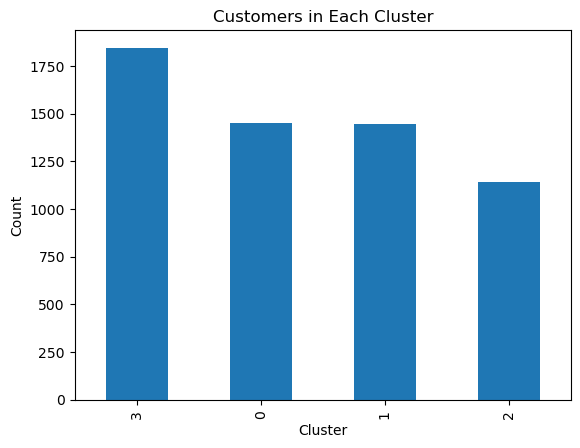

In [76]:
# visual
rfm['cluster'].value_counts().plot(kind='bar')

plt.title("Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()

In [77]:
# segment mapping
segment_map = {
    0: "At Risk / Potential Loyal",
    1: "Champions / VIP",
    2: "New / Occasional",
    3: "Lost Customers"
}

rfm['segment'] = rfm['cluster'].map(segment_map)

In [78]:
rfm.head()

,recency,frequency,monetary,cluster,segment
Customer ID,,,,,
12346,5.789960,2.564949,8.538630,0,At Risk / Potential Loyal
12347,1.098612,2.197225,8.501578,1,Champions / VIP
12348,4.330733,1.791759,7.611051,0,At Risk / Potential Loyal
12349,2.995732,1.609438,8.396085,1,Champions / VIP
12350,5.739793,0.693147,5.815324,3,Lost Customers


In [79]:
# segment counts 
rfm['segment'].value_counts()

segment
Lost Customers               1845
At Risk / Potential Loyal    1449
Champions / VIP              1444
New / Occasional             1140
Name: count, dtype: int64

# Store Final data 

In [80]:
# Store Final data 
rfm.to_csv("customer_segments_final.csv")

In [81]:
# save to database 
import sqlite3
# Step 1: Create connection
conn = sqlite3.connect("customer_segments.db")

In [82]:
# save as table 
rfm.to_sql("customer_segments", conn, if_exists="replace", index=True)

5878

In [83]:
# close 
conn.close()

In [84]:
# test 
conn = sqlite3.connect("customer_segments.db")

df_check = pd.read_sql("SELECT * FROM customer_segments LIMIT 5", conn)

conn.close()

print(df_check)

   Customer ID   recency  frequency  monetary  cluster  \
0        12346  5.789960   2.564949  8.538630        0   
1        12347  1.098612   2.197225  8.501578        1   
2        12348  4.330733   1.791759  7.611051        0   
3        12349  2.995732   1.609438  8.396085        1   
4        12350  5.739793   0.693147  5.815324        3   

                     segment  
0  At Risk / Potential Loyal  
1            Champions / VIP  
2  At Risk / Potential Loyal  
3            Champions / VIP  
4             Lost Customers  


In [85]:
# insights using sql 
conn = sqlite3.connect("customer_segments.db")

segment_summary = pd.read_sql("""
SELECT segment,
       COUNT(*) as total_customers,
       AVG(recency) as avg_recency,
       AVG(frequency) as avg_frequency,
       AVG(monetary) as avg_monetary
FROM customer_segments
GROUP BY segment
""", conn)

conn.close()

print(segment_summary)

                     segment  total_customers  avg_recency  avg_frequency  \
0  At Risk / Potential Loyal             1449     5.301505       1.647040   
1            Champions / VIP             1444     2.855540       2.474849   
2             Lost Customers             1845     5.835309       0.816067   
3           New / Occasional             1140     3.166631       1.229434   

   avg_monetary  
0      7.221816  
1      8.161849  
2      5.448502  
3      6.389766  


# Visualize Final Segments

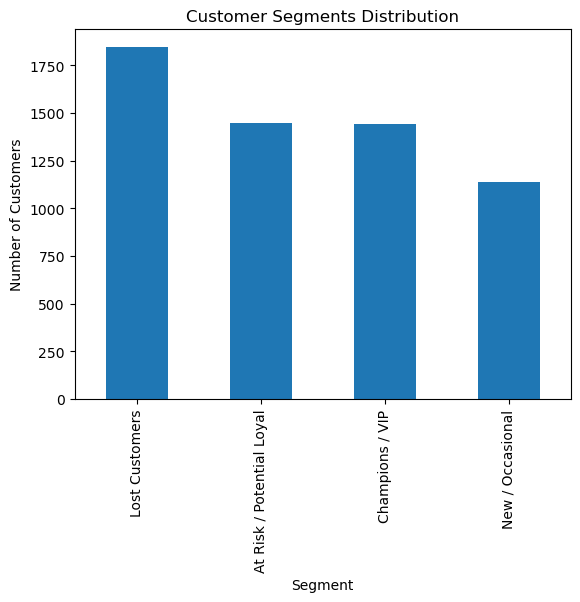

In [86]:
# Segment Count Bar Chart
import matplotlib.pyplot as plt

rfm['segment'].value_counts().plot(kind='bar')

plt.title("Customer Segments Distribution")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.show()

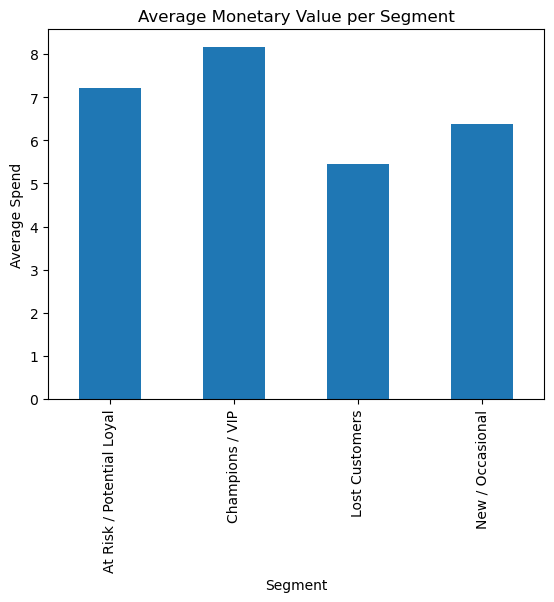

In [87]:
# Segment vs Monetary Value
rfm.groupby('segment')['monetary'].mean().plot(kind='bar')

plt.title("Average Monetary Value per Segment")
plt.xlabel("Segment")
plt.ylabel("Average Spend")
plt.show()

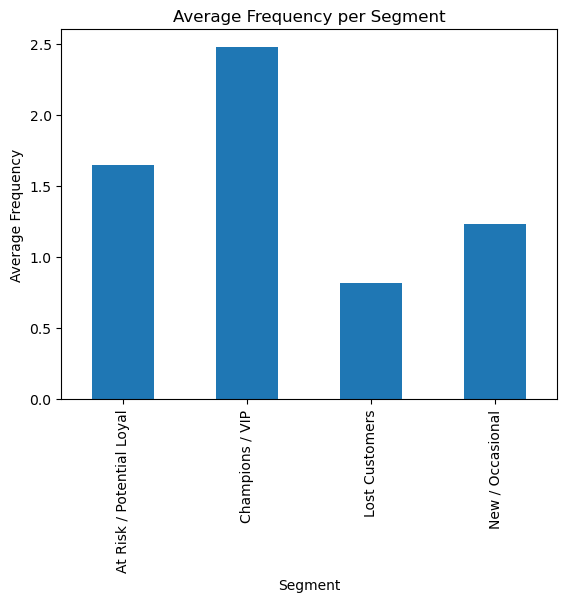

In [88]:
# Segment vs Frequency
rfm.groupby('segment')['frequency'].mean().plot(kind='bar')

plt.title("Average Frequency per Segment")
plt.xlabel("Segment")
plt.ylabel("Average Frequency")
plt.show()

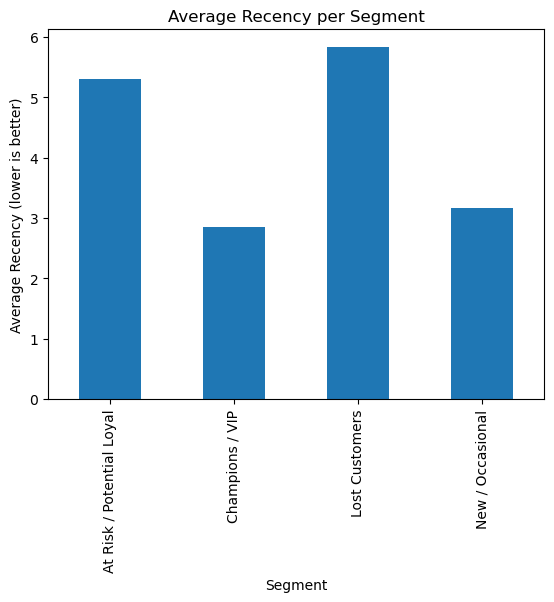

In [89]:
# Segment vs Recency
rfm.groupby('segment')['recency'].mean().plot(kind='bar')

plt.title("Average Recency per Segment")
plt.xlabel("Segment")
plt.ylabel("Average Recency (lower is better)")
plt.show()

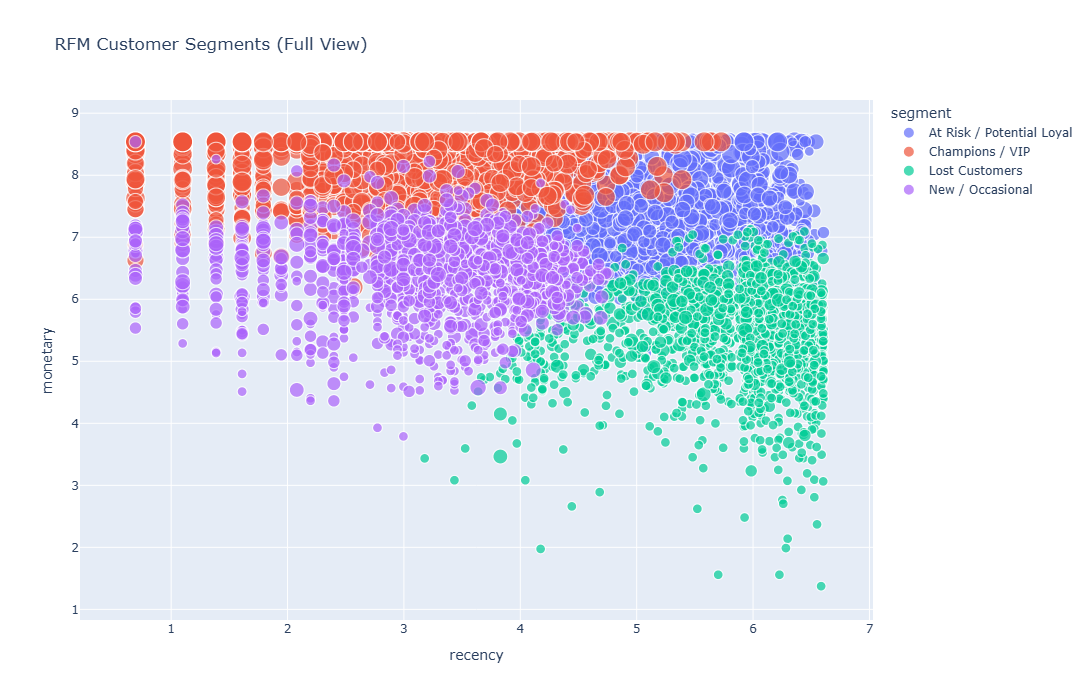

In [95]:
import plotly.express as px

fig = px.scatter(
    rfm,
    x='recency',
    y='monetary',
    size='frequency',
    color='segment',
    hover_data=['recency', 'frequency', 'monetary'],
    title="RFM Customer Segments (Full View)"
)

fig.update_layout(
    width=1000,
    height=700
)

fig.show()